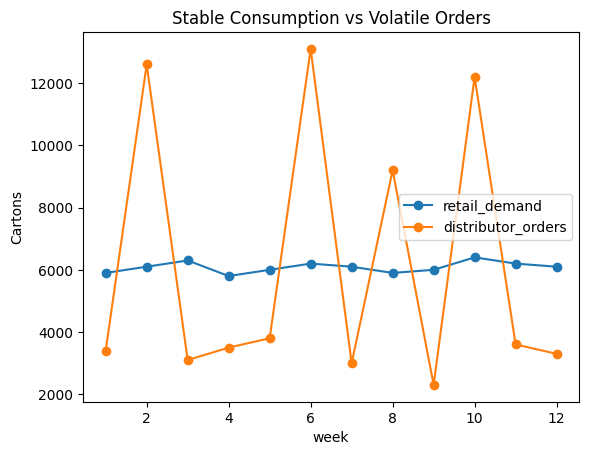

retail_demand mean= 6083.3 sd= 174.9 CV= 0.029
distributor_orders mean= 6091.7 sd= 4312.2 CV= 0.708
semolina_tonnes mean= 38.3 sd= 36.0 CV= 0.939
Bullwhip ratio: 607.6
                  count         mean          std
commercial_event                                 
0                     7  3385.714286   279.455252
1                     5  9880.000000  4501.888493
    week                   event  order_to_demand
0      1                                 0.576271
1      2             Mega Scheme         2.065574
2      3                                 0.492063
3      4                                 0.603448
4      5                                 0.633333
5      6             Mega Scheme         2.112903
6      7                                 0.491803
7      8    Price rise announced         1.559322
8      9  New price takes effect         0.383333
9     10             Mega Scheme         1.906250
10    11                                 0.580645
11    12                        

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "week": range(1, 13),
    "event": ["","Mega Scheme","","","","Mega Scheme","",
              "Price rise announced","New price takes effect",
              "Mega Scheme","",""],
    "retail_demand": [5900,6100,6300,5800,6000,6200,6100,5900,6000,6400,6200,6100],
    "distributor_orders": [3400,12600,3100,3500,3800,13100,3000,9200,2300,12200,3600,3300],
    "semolina_tonnes": [10,90,30,10,30,95,5,70,0,85,20,15]
})

# 1) Visual diagnosis
df.plot(x="week", y=["retail_demand","distributor_orders"], marker="o")
plt.ylabel("Cartons")
plt.title("Stable Consumption vs Volatile Orders")
plt.show()

# 2) Descriptive analytics
for col in ["retail_demand","distributor_orders","semolina_tonnes"]:
    mean = df[col].mean()
    sd = df[col].std()                 # sample SD
    cv = sd / mean
    print(col, "mean=", round(mean,1), "sd=", round(sd,1), "CV=", round(cv,3))

# 3) Bullwhip ratio
bullwhip = df["distributor_orders"].var() / df["retail_demand"].var()
print("Bullwhip ratio:", round(bullwhip,1))

# 4) Event analytics
df["scheme"] = df["event"].str.contains("Mega", case=False).astype(int)
df["price_event"] = df["event"].str.contains("price", case=False).astype(int)
df["commercial_event"] = ((df["scheme"] + df["price_event"]) > 0).astype(int)
print(df.groupby("commercial_event")["distributor_orders"].agg(["count","mean","std"]))

# 5) Optional: compare orders with retail demand
df["order_to_demand"] = df["distributor_orders"] / df["retail_demand"]
print(df[["week","event","order_to_demand"]])

# 6) Pilot KPI improvement
pilot = pd.DataFrame({
    "metric": ["Order CV","Stockout rate","Stock cover days"],
    "before": [58,6.8,15],
    "during": [17,2.9,9]
})
pilot["pct_improvement"] = (pilot["before"] - pilot["during"]) / pilot["before"] * 100
print(pilot)

### Simulation: Shared Demand vs. Distributor-Led Production planning

Below, we compare the current raw materials (Semolina) ordering volatility under the traditional model against a **Collaborative Model** where production planning is linked directly to the actual retail demand (with a small buffer for safety stock).

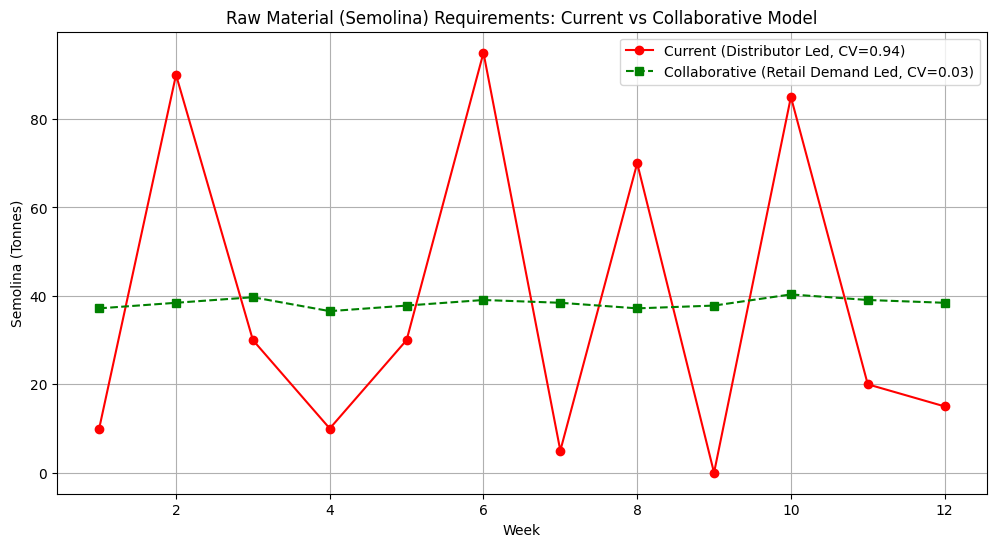

Current Semolina Variance (Variance): 1297.0
Collaborative Semolina Variance (Variance): 1.2
Reduction in Raw Material demand volatility: 99.9%


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming a conversion factor where retail demand of cartons requires raw material semolina
# Under the current distributor model, semolina tonnes are highly volatile:
current_semolina_cv = df["semolina_tonnes"].std() / df["semolina_tonnes"].mean()

# Collaborative model: Base semolina production directly on retail demand
# Let's say 1000 cartons of retail demand require roughly 6.3 tonnes of semolina on average
conversion_factor = df["semolina_tonnes"].sum() / df["retail_demand"].sum()

# Collaborative raw material requirements directly aligned with stable retail demand
df["collaborative_semolina"] = df["retail_demand"] * conversion_factor

col_semolina_mean = df["collaborative_semolina"].mean()
col_semolina_sd = df["collaborative_semolina"].std()
col_semolina_cv = col_semolina_sd / col_semolina_mean

# Compare the volatility visually
plt.figure(figsize=(12, 6))
plt.plot(df["week"], df["semolina_tonnes"], marker="o", label=f"Current (Distributor Led, CV={current_semolina_cv:.2f})", color="red")
plt.plot(df["week"], df["collaborative_semolina"], marker="s", label=f"Collaborative (Retail Demand Led, CV={col_semolina_cv:.2f})", color="green", linestyle="--")
plt.title("Raw Material (Semolina) Requirements: Current vs Collaborative Model")
plt.xlabel("Week")
plt.ylabel("Semolina (Tonnes)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Current Semolina Variance (Variance): {df['semolina_tonnes'].var():.1f}")
print(f"Collaborative Semolina Variance (Variance): {df['collaborative_semolina'].var():.1f}")
print(f"Reduction in Raw Material demand volatility: {((df['semolina_tonnes'].var() - df['collaborative_semolina'].var()) / df['semolina_tonnes'].var() * 100):.1f}%")
